In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
import os 
print(os.getcwd())

c:\Users\mzbur\project-3\notebooks


In [4]:
import os 
files = os.listdir('../data/')
print(files)

['all-data.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [8]:
df = pd.read_csv(r'C:\Users\mzbur\project-3\data\WA_Fn-UseC_-Telco-Customer-Churn.csv') 

print("Data loaded!")
print("Rows and columns:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nChurn distribution")
print(df['Churn'].value_counts())

Data loaded!
Rows and columns: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen  ... MonthlyCharges TotalCharges  Churn
0  7590-VHVEG  Female              0  ...          29.85        29.85     No
1  5575-GNVDE    Male              0  ...          56.95       1889.5     No
2  3668-QPYBK    Male              0  ...          53.85       108.15    Yes
3  7795-CFOCW    Male              0  ...          42.30      1840.75     No
4  9237-HQITU  Female              0  ...          70.70       151.65    Yes

[5 rows x 21 columns]

Churn distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender  

In [13]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges is NaN
df = df.dropna(subset=['TotalCharges'])

# Convert Churn to binary 0/1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID - not useful for prediction
df = df.drop('customerID', axis=1)

print("Data cleaned!")
print("Rows remaining:", len(df))
print("Churn distribution:")
print(df['Churn'].value_counts())

Data cleaned!
Rows remaining: 7032
Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [14]:
# Encode all categorical columns
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns
print("Encoding these columns:", categorical_cols.to_list())

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nAll columns now numeric:")
print(df.dtypes)

Encoding these columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

All columns now numeric:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [15]:
# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2,
                                                      random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Features:", X.columns.to_list())

Training rows: 5625
Testing rows: 1407
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [16]:
# Model 1 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Model 2 - Random Forest 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Model 3 - XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("All models trained!")
print(f"Logistic Regression Accuracy: {lr_accuracy: .2%}")
print(f"Random Forest Accuracy:       {rf_accuracy: .2%}")
print(f"XGBoost Accuracy:             {xgb_accuracy: .2%}")

c:\Users\mzbur\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


All models trained!
Logistic Regression Accuracy:  78.61%
Random Forest Accuracy:        79.25%
XGBoost Accuracy:              76.40%


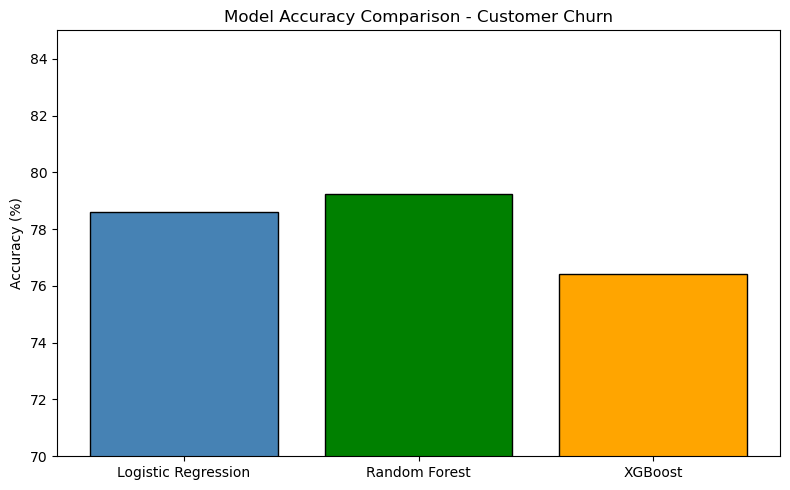

Chart saved!


In [17]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [lr_accuracy, rf_accuracy, xgb_accuracy]
colors = ['steelblue', 'green', 'orange']

plt.figure(figsize=(8, 5))
plt.bar(models, [a * 100 for a in accuracies],
        color=colors, edgecolor='black')
plt.title('Model Accuracy Comparison - Customer Churn')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 85)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

print("Chart saved!")

In [25]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

print("Type:", type(shap_values))
print("Length:", len(shap_values))
if isinstance(shap_values, list):
    print("Shape of each element:")
    for i, sv in enumerate(shap_values):
        print(f" Index {i}:", sv.shape)

else:
    print("Shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
Length: 1407
Shape: (1407, 19, 2)


In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Recreate explainer fresh
tree_explainer = shap.TreeExplainer(rf_model)
sv = tree_explainer.shap_values(X_test)

print("Shape:", np.array(sv).shape)

Shape: (1407, 19, 2)


Extracted shape: (1407, 19)


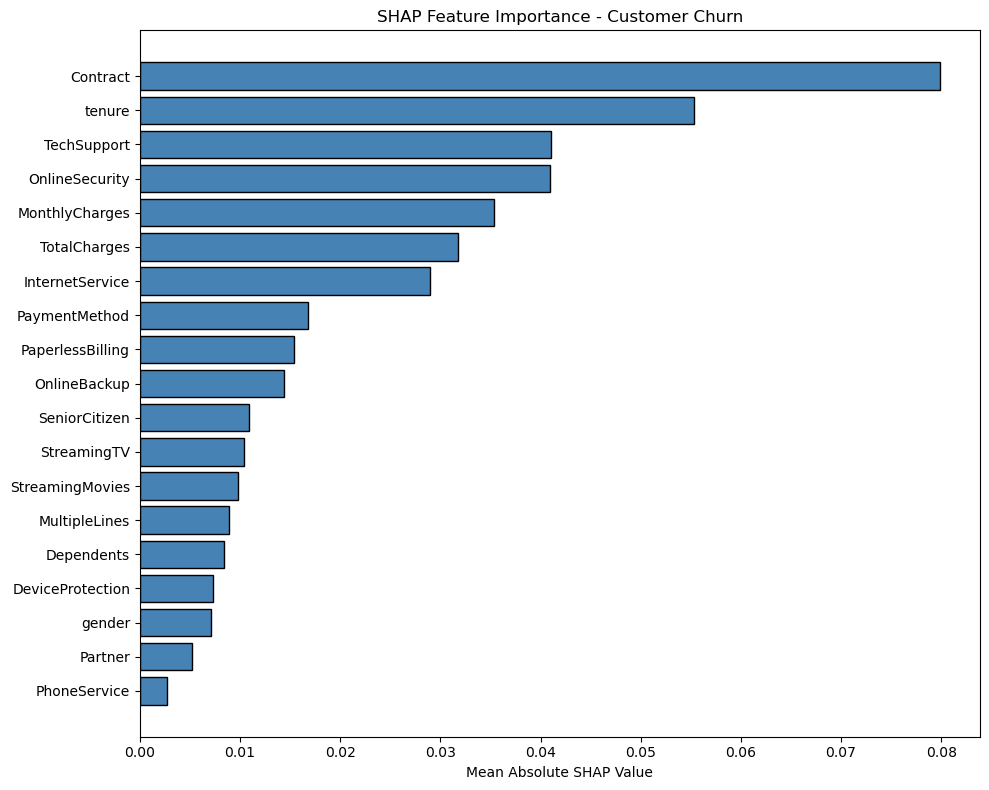

SHAP chart saved!


In [31]:
# Extract churn-Yes class (last dimension index 1)
sv_churn = np.array(sv)[:, :, 1]
print("Extracted shape:", sv_churn.shape)

# Mean absolute SHAP per feature
mean_shap = np.abs(sv_churn).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': mean_shap
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'],
         feature_importance['importance'],
         color='steelblue', edgecolor='black')
plt.title('SHAP Feature Importance - Customer Churn')
plt.xlabel('Mean Absolute SHAP Value')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', bbox_inches='tight')
plt.show()

print("SHAP chart saved!")

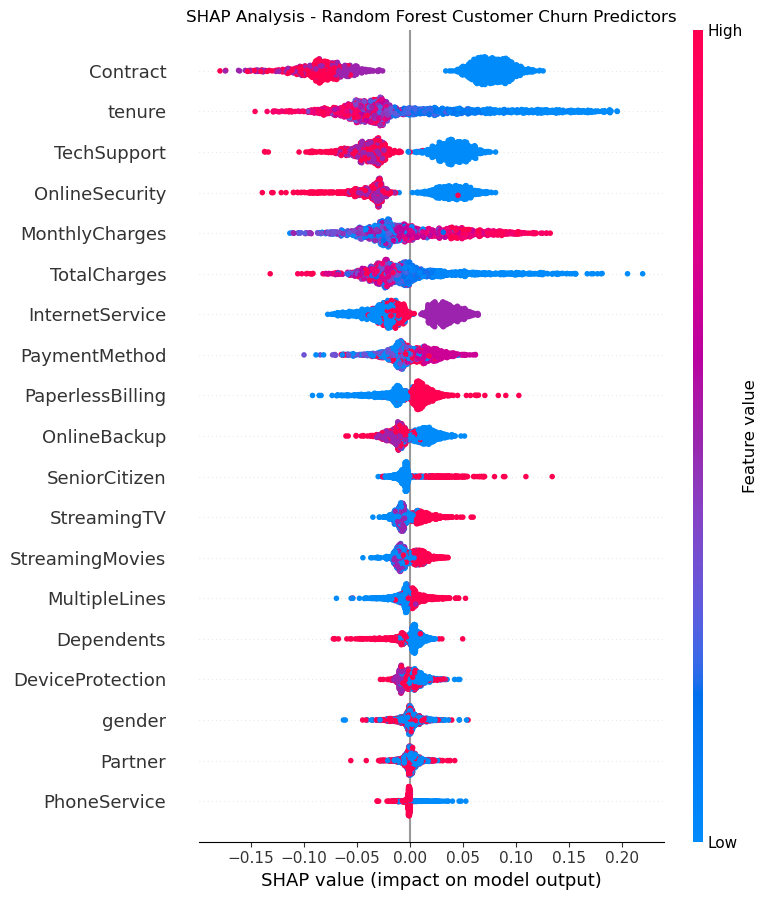

In [33]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_churn, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Analysis - Random Forest Customer Churn Predictors')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', bbox_inches='tight')
plt.show()